In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [2]:
REGION = 'Nord'
YEARS = range(2015, 2026)

In [3]:
datasets = []

for YEAR in YEARS:
    print(f"Reading data for Cameroon {REGION} in {YEAR}")
    # Load the dataset for the specified year
    datasets.append(pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc))

# Concatenate all datasets into a single DataFrame
df = pd.concat(datasets, ignore_index=True)

try:
    df.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

Reading data for Cameroon Nord in 2015
Reading data for Cameroon Nord in 2016
Reading data for Cameroon Nord in 2017
Reading data for Cameroon Nord in 2018
Reading data for Cameroon Nord in 2019
Reading data for Cameroon Nord in 2020
Reading data for Cameroon Nord in 2021
Reading data for Cameroon Nord in 2022
Reading data for Cameroon Nord in 2023
Reading data for Cameroon Nord in 2024
Reading data for Cameroon Nord in 2025


In [4]:
print(df.shape)

df.head()

(18500, 76)


,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,26.16,35.56,16.76,0.0,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2014,2014-12,29.50,22.50,60.81,276.34,51.0,14.0,37.0,26.33,28.83,33.33,26.33,1968.0,537.0,0.0,114.71,1294.0,1.0,240.0,1294.0,14.83,43.07,0.0000
1,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,26.44,35.18,17.70,0.0,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2014,2014-12,29.33,20.50,60.29,349.24,50.0,16.0,34.0,25.83,29.17,34.33,25.67,2013.0,583.0,0.0,120.04,1353.0,2.0,94.0,1275.0,16.16,41.82,0.1626
2,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,26.59,35.35,17.83,0.0,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2014,2014-12,30.08,21.17,58.80,308.10,51.0,15.0,36.0,27.50,30.33,34.50,26.83,1845.0,540.0,0.0,120.79,1240.0,0.0,81.0,1178.0,16.33,41.81,0.1093
3,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,24.94,33.78,16.10,0.0,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,1,6,7,2014,2014-12,29.17,22.00,61.11,310.67,49.0,13.0,36.0,25.83,28.00,33.67,25.83,2049.0,539.0,0.0,112.59,1314.0,1.0,243.0,1314.0,13.40,41.73,0.3455
4,2015-01,2015,1,2014,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,26.33,34.23,18.42,0.0,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2014,2014-12,30.25,20.17,56.02,284.05,51.0,15.0,36.0,28.00,29.00,34.00,28.00,1872.0,521.0,0.0,119.39,1228.0,0.0,98.0,997.0,15.58,41.15,0.2733


Text(0.5, 1.0, 'Years: 2015 - 2025')

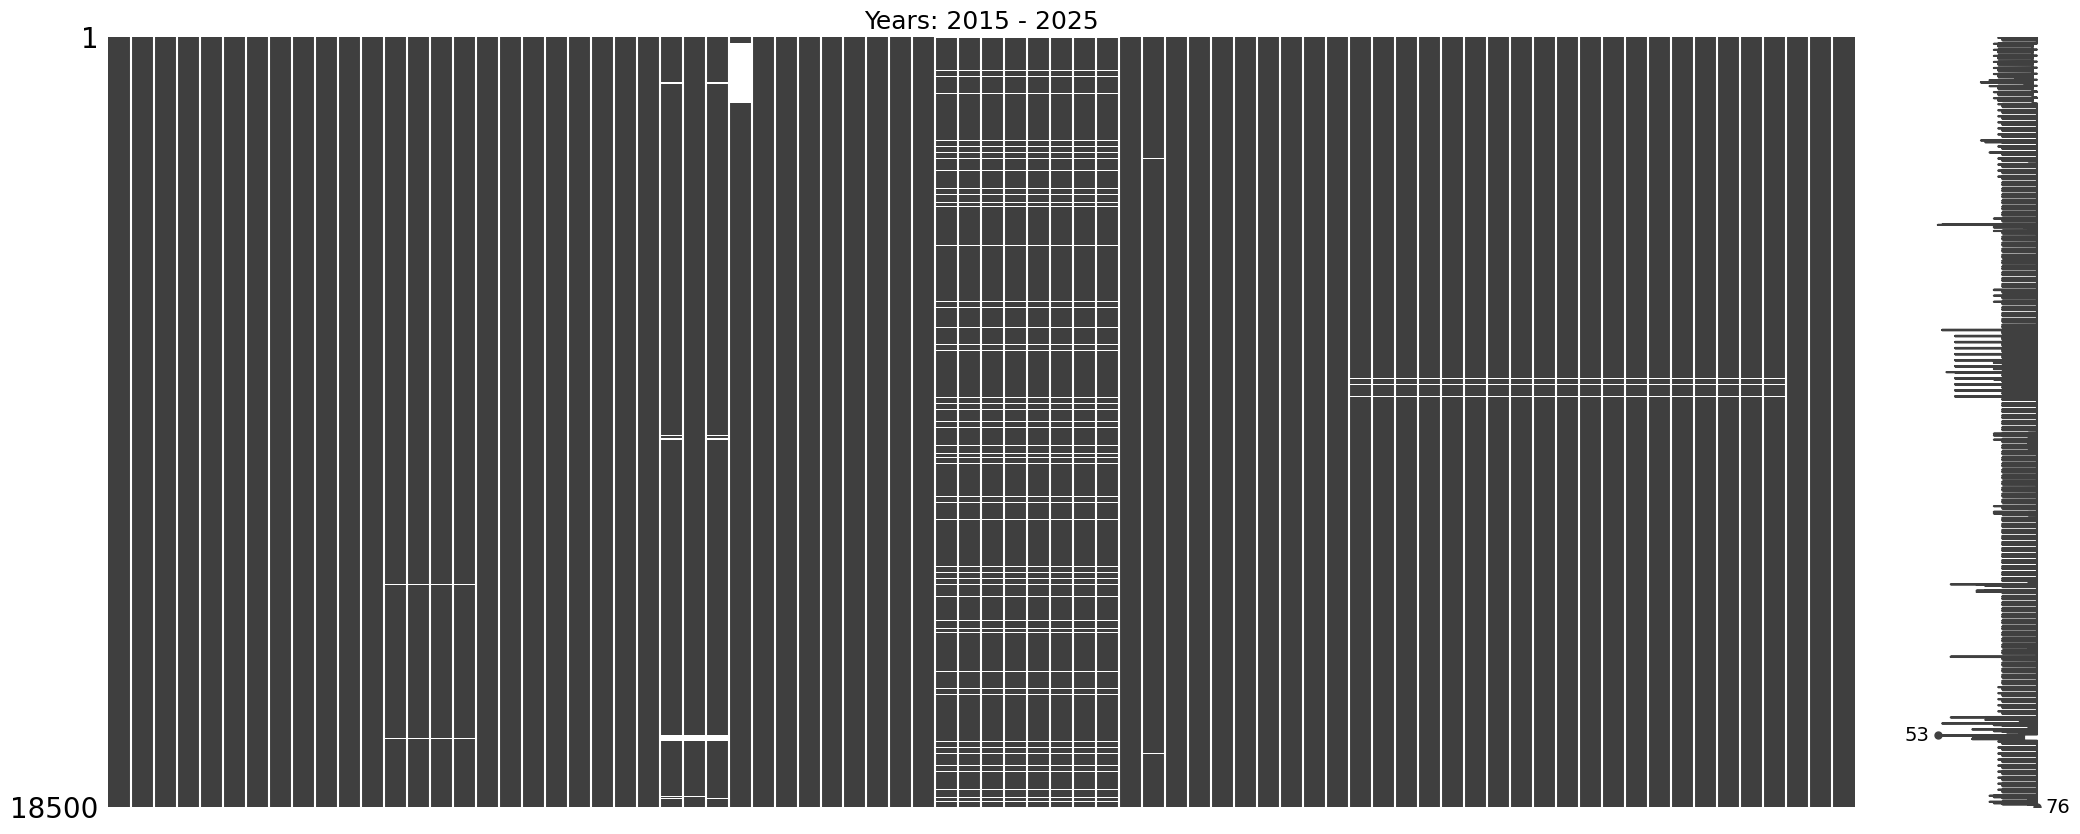

In [5]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Years: {min(YEARS)} - {max(YEARS)}", fontsize=18)

In [6]:
df['dt_placement'] = pd.to_datetime(df['dt_placement']).dt.to_period('M')
df['dt_weather_acc'] = pd.to_datetime(df['dt_weather_acc']).dt.to_period('M')
df.rename(columns={'dt_placement': 'dt_prediction'}, inplace=True)
df['location'] = list(zip(df['GID0'], df['GID2'], df['GID3']))

In [7]:
dataset_final = df.copy()

In [8]:
len(dataset_final.columns.to_list())


77

In [9]:
rearranged_columns = ['location','GID0','GID1','GID2','GID3','x','y',
 'dt_prediction','year', 'month','month_sin','month_cos', 'dt_weather_acc', 'year_biovars', 'year_lc',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst','lst_day','lst_night','lst_min_prev_month','lst_max_prev_month',
 'rainfall','rainfall_acc_prev_month',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']

In [10]:
dataset_final= dataset_final[rearranged_columns].copy()

In [11]:
dataset_final.head()

,location,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"(nord, bibemi, adoumri)",nord,benoue,bibemi,adoumri,13.770202,9.240232,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,26.16,35.56,16.76,14.83,43.07,0.0,0.0000,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,29.50,22.50,60.81,276.34,51.0,14.0,37.0,26.33,28.83,33.33,26.33,1968.0,537.0,0.0,114.71,1294.0,1.0,240.0,1294.0
1,"(nord, bibemi, bibemi)",nord,benoue,bibemi,bibemi,13.949181,9.263633,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,26.44,35.18,17.70,16.16,41.82,0.0,0.1626,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,29.33,20.50,60.29,349.24,50.0,16.0,34.0,25.83,29.17,34.33,25.67,2013.0,583.0,0.0,120.04,1353.0,2.0,94.0,1275.0
2,"(nord, bibemi, bide)",nord,benoue,bibemi,bide,13.972945,9.422292,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,26.59,35.35,17.83,16.33,41.81,0.0,0.1093,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,30.08,21.17,58.80,308.10,51.0,15.0,36.0,27.50,30.33,34.50,26.83,1845.0,540.0,0.0,120.79,1240.0,0.0,81.0,1178.0
3,"(nord, bibemi, dengui)",nord,benoue,bibemi,dengui,13.642496,9.235656,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,24.94,33.78,16.10,13.40,41.73,0.0,0.3455,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,1,6,7,29.17,22.00,61.11,310.67,49.0,13.0,36.0,25.83,28.00,33.67,25.83,2049.0,539.0,0.0,112.59,1314.0,1.0,243.0,1314.0
4,"(nord, bibemi, djaloumi)",nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,26.33,34.23,18.42,15.58,41.15,0.0,0.2733,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,30.25,20.17,56.02,284.05,51.0,15.0,36.0,28.00,29.00,34.00,28.00,1872.0,521.0,0.0,119.39,1228.0,0.0,98.0,997.0


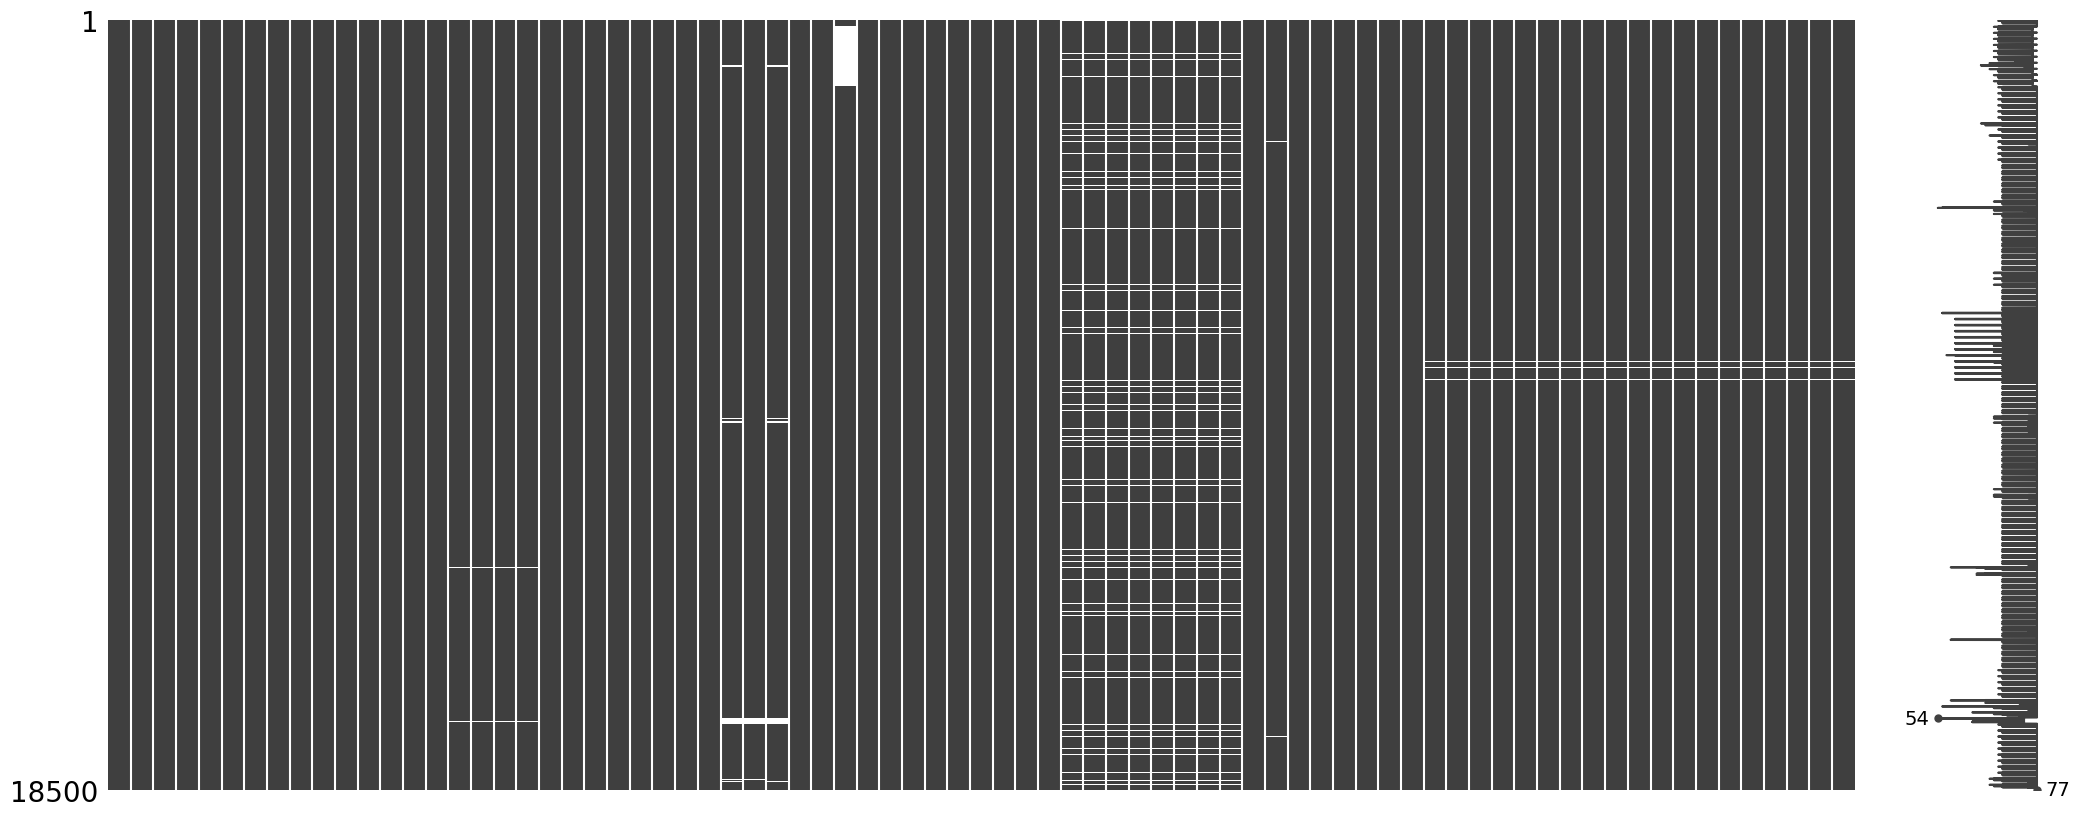

In [12]:
msno.matrix(dataset_final, label_rotation=90)
ax = plt.gca()

In [13]:
dataset_final.drop(columns=['location'], inplace=True)
dataset_final.reset_index(drop=True, inplace=True)
for col in dataset_final.select_dtypes(include='float').columns:
    if dataset_final[col].dropna().apply(float.is_integer).all():
        dataset_final[col] = dataset_final[col].astype('Int64')

In [14]:
dataset_final

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,nord,benoue,bibemi,adoumri,13.770202,9.240232,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.160002,-0.120537,-0.342115,0.120537,0.164934,-0.117264,-0.346438,0.117264,0.008212,0.013665,0.015085,0.013665,26.16,35.56,16.76,14.83,43.07,0.0000,0.0000,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,29.50,22.50,60.81,276.34,51,14,37,26.33,28.83,33.33,26.33,1968,537,0,114.71,1294,1,240,1294
1,nord,benoue,bibemi,bibemi,13.949181,9.263633,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.180811,-0.103038,-0.337729,0.103038,0.180456,-0.102711,-0.336806,0.102711,0.010560,0.011225,0.011200,0.011225,26.44,35.18,17.70,16.16,41.82,0.0000,0.1626,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,29.33,20.50,60.29,349.24,50,16,34,25.83,29.17,34.33,25.67,2013,583,0,120.04,1353,2,94,1275
2,nord,benoue,bibemi,bide,13.972945,9.422292,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.172986,-0.089423,-0.323776,0.089423,0.177404,-0.085450,-0.325494,0.085450,0.008799,0.009392,0.009824,0.009392,26.59,35.35,17.83,16.33,41.81,0.0000,0.1093,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,30.08,21.17,58.80,308.10,51,15,36,27.50,30.33,34.50,26.83,1845,540,0,120.79,1240,0,81,1178
3,nord,benoue,bibemi,dengui,13.642496,9.235656,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.178563,-0.067295,-0.292543,0.067295,0.180811,-0.066269,-0.294958,0.066269,0.012477,0.018840,0.018732,0.018840,24.94,33.78,16.10,13.40,41.73,0.0000,0.3455,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,1,6,7,29.17,22.00,61.11,310.67,49,13,36,25.83,28.00,33.67,25.83,2049,539,0,112.59,1314,1,243,1314
4,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.181085,-0.013806,-0.254480,0.013806,0.183872,-0.008080,-0.256086,0.008080,0.023456,0.022051,0.047988,0.022051,26.33,34.23,18.42,15.58,41.15,0.0000,0.2733,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,30.25,20.17,56.02,284.05,51,15,36,28.00,29.00,34.00,28.00,1872,521,0,119.39,1228,0,98,997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18495,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2025-08,2025,8,-0.866,-0.500,2025-07,2024,2024,0.584817,0.269254,-0.293034,-0.269254,0.569654,0.265639,-0.290047,-0.265639,0.059816,0.039034,0.044323,0.039034,20.74,25.28,16.16,15.27,25.34,15.9897,334.6843,125988.49,1351.46,5.49,165.60,710.63,180.16,0.0,416.45,9674.69,975.21,6.24,51.83,161.28,6.21,0.0,3164.67,22,20,20,9,9,4,4,4,25.38,13.42,49.69,322.01,41,14,27,22.83,22.83,29.83,22.83,2887,796,0,111.36,1749,0,288,1749
18496,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2025-08,2025,8,-0.866,-0.500,2025-07,2024,2024,0.611910,0.249040,-0.357736,-0.249040,0.536293

In [15]:
dataset_final.to_csv(f'../../data/{REGION}/CM_{REGION}_Test_Dataset_2015-2025.csv', index=False,  encoding=enc)